# Task 1 — Direct Preference Optimization

Experiments:
1. Standard DPO: one epoch.
2. Beta study: β ∈ {0.03, 0.10, 0.30}, 600 training pairs each.
3. Length-confounding study: standard versus length-balanced DPO.



In [ ]:
from pathlib import Path
import os
import subprocess
import sys

if Path('task1_dpo').is_dir():
    repo = Path.cwd()
elif (Path.cwd().parent / 'task1_dpo').is_dir():
    repo = Path.cwd().parent
else:
    from google.colab import drive
    drive.mount('/content/drive')
    repo = Path('/content/drive/MyDrive/ATML/PA2/ATML-PA2-LLM-PostTraining')
assert (repo / 'task1_dpo').is_dir(), f'Repository not found: {repo}'
os.chdir(repo)
print('Repository:', repo)


## Reproduction

Install requirements and download/validate course assets before a fresh run.
GPU cells below are disabled by default. Preserve published results and existing
adapters before independent reproduction, as described in the top-level README.
Saved tables and figures can be inspected on CPU without retraining.


In [ ]:
RUN_STANDARD_GPU = False

if RUN_STANDARD_GPU:
    import torch
    assert torch.cuda.is_available(), "Select a GPU runtime."
    commands = [['task1_dpo.train', '--config', 'configs/dpo.yaml', '--run-name', 'standard', '--output', 'outputs/task1_dpo/standard'], ['task1_dpo.evaluate', '--config', 'configs/dpo.yaml', '--adapter', 'outputs/task1_dpo/standard', '--name', 'standard']]
    for args in commands:
        command = [sys.executable, '-u', '-m', *args]
        print('Running:', ' '.join(command), flush=True)
        subprocess.run(command, check=True)
else:
    print('GPU reproduction disabled.')


In [ ]:
RUN_BETA_GPU = False

if RUN_BETA_GPU:
    import torch
    assert torch.cuda.is_available(), "Select a GPU runtime."
    commands = [['task1_dpo.ablate_beta', '--config', 'configs/dpo.yaml', '--stage', 'train'], ['task1_dpo.ablate_beta', '--config', 'configs/dpo.yaml', '--stage', 'evaluate']]
    for args in commands:
        command = [sys.executable, '-u', '-m', *args]
        print('Running:', ' '.join(command), flush=True)
        subprocess.run(command, check=True)
else:
    print('GPU reproduction disabled.')


In [ ]:
RUN_LENGTH_GPU = False

if RUN_LENGTH_GPU:
    import torch
    assert torch.cuda.is_available(), "Select a GPU runtime."
    commands = [['task1_dpo.analyze_length', '--config', 'configs/dpo.yaml', '--stage', 'all']]
    for args in commands:
        command = [sys.executable, '-u', '-m', *args]
        print('Running:', ' '.join(command), flush=True)
        subprocess.run(command, check=True)
else:
    print('GPU reproduction disabled.')


In [2]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display

results = Path("results/task1_dpo")

def load_json(filename):
    return json.loads((results / filename).read_text())

rows = []
for name in ["standard", "beta_0p03", "beta_0p10", "beta_0p30"]:
    evaluation = load_json(f"{name}_eval_summary.json")
    training = load_json(f"{name}_summary.json")

    rows.append({
        "Run": name,
        "Training pairs": training["num_examples"],
        "Updates": training["optimizer_updates"],
        "Skipped updates": training["skipped_updates"],
        "Beta": evaluation["beta"],
        "Held-out loss": evaluation["heldout_dpo_loss"],
        "Preference accuracy": evaluation["heldout_preference_accuracy"],
        "Sampled KL/token": evaluation["sampled_kl_token_mean"],
        "Reward score": evaluation["reward_model_score_mean"],
        "Length mean": evaluation["response_length_mean"],
        "Length std": evaluation["response_length_std"],
        "Generation cap rate": evaluation["generation_cap_rate"],
    })

display(pd.DataFrame(rows).round(6))

length = load_json("length_study_summary.json")

strata_rows = []
generation_rows = []
for name, values in length.items():
    for stratum, metrics in values["strata"].items():
        strata_rows.append({
            "Policy": name,
            "Stratum": stratum,
            "Pairs": metrics["num_pairs"],
            "Preference accuracy": metrics["preference_accuracy"],
        })

    generation_rows.append({
        "Policy": name,
        "Prompts": values["word_prompt_count"],
        "Word-limit compliance": values["word_limit_compliance"],
        "Length mean": values["word_prompt_response_length_mean"],
        "Length std": values["word_prompt_response_length_std"],
        "Generation cap rate": values["word_prompt_generation_cap_rate"],
    })

display(pd.DataFrame(strata_rows).round(4))
display(pd.DataFrame(generation_rows).round(4))

,Run,Training pairs,Updates,Skipped updates,Beta,Held-out loss,Preference accuracy,Sampled KL/token,Reward score,Length mean,Length std,Generation cap rate
0,standard,1446,90,1,0.10,0.674988,0.648276,0.000040,1.363794,154.624138,105.927171,0.441379
1,beta_0p03,600,38,0,0.03,0.691258,0.617241,-0.000292,1.339666,154.789655,104.844222,0.441379
2,beta_0p10,600,38,0,0.10,0.687915,0.579310,-0.000239,1.317023,155.010345,105.109811,0.448276
3,beta_0p30,600,36,2,0.30,0.679689,0.603448,-0.000335,1.331183,155.282759,105.131163,0.444828


,Policy,Stratum,Pairs,Preference accuracy
0,standard,length_matched,80,0.5375
1,standard,preferred_longer,78,0.4487
2,standard,rejected_longer,79,0.6709
3,length_balanced,length_matched,80,0.6125
4,length_balanced,preferred_longer,78,0.4872
5,length_balanced,rejected_longer,79,0.7468


,Policy,Prompts,Word-limit compliance,Length mean,Length std,Generation cap rate
0,standard,10,0.6,46.8,23.7310,0.0
1,length_balanced,10,0.5,43.2,15.6384,0.0


In [3]:
def read_jsonl(filename):
    return [
        json.loads(line)
        for line in (results / filename).read_text().splitlines()
        if line.strip()
    ]

print("Reward comparison — evaluation row 41")
for name in ["standard", "beta_0p03"]:
    generations = {
        r["row_index"]: r
        for r in read_jsonl(f"{name}_generations.jsonl")
    }
    rewards = {
        r["row_index"]: r
        for r in read_jsonl(f"{name}_rewards.jsonl")
    }
    record = generations[41]

    if name == "standard":
        print("Prompt:", record["prompt_messages"])

    print(f"\n{name}: reward={rewards[41]['reward']:.4f}")
    print(record["response"])

print("\nWord-limit comparison — prompt 5")
for name in ["standard", "length_balanced"]:
    records = {
        r["prompt_index"]: r
        for r in read_jsonl(f"length_study_{name}_word_limits.jsonl")
    }
    record = records[5]

    if name == "standard":
        print("Prompt:", record["prompt_messages"])

    print(
        f"\n{name}: words={record['word_count']}, "
        f"compliant={record['word_limit_compliant']}"
    )
    print(record["response"])

Reward comparison — evaluation row 41
Prompt: [{'content': 'pls tell me the size of the earth', 'role': 'user'}]

standard: reward=2.4980
The Earth's average radius is approximately 6,371 kilometers (about 3,959 miles). This measurement includes both the diameter and circumference. The Earth has several different radii:

1. **Equatorial Radius**: The distance from the center of the Earth to its surface at the equator.
   - Diameter: Approximately 12,742 kilometers (7,918 miles)
   - Circumference: About 40,075 kilometers (24,860 miles)

2. **Polar Radius**: The distance from the center of the Earth to its surface at the poles.
   - Diameter: Approximately 12,714 kilometers (7,902 miles)
   - Circumference: About 40,008 kilometers (24,860 miles)

3. **Geocentric Radius**: From the center of the Earth to any point on the surface.

These measurements can vary slightly due to the fact that the Earth isn't perfectly spherical; it bulges at the equator and is slightly flattened at the poles.

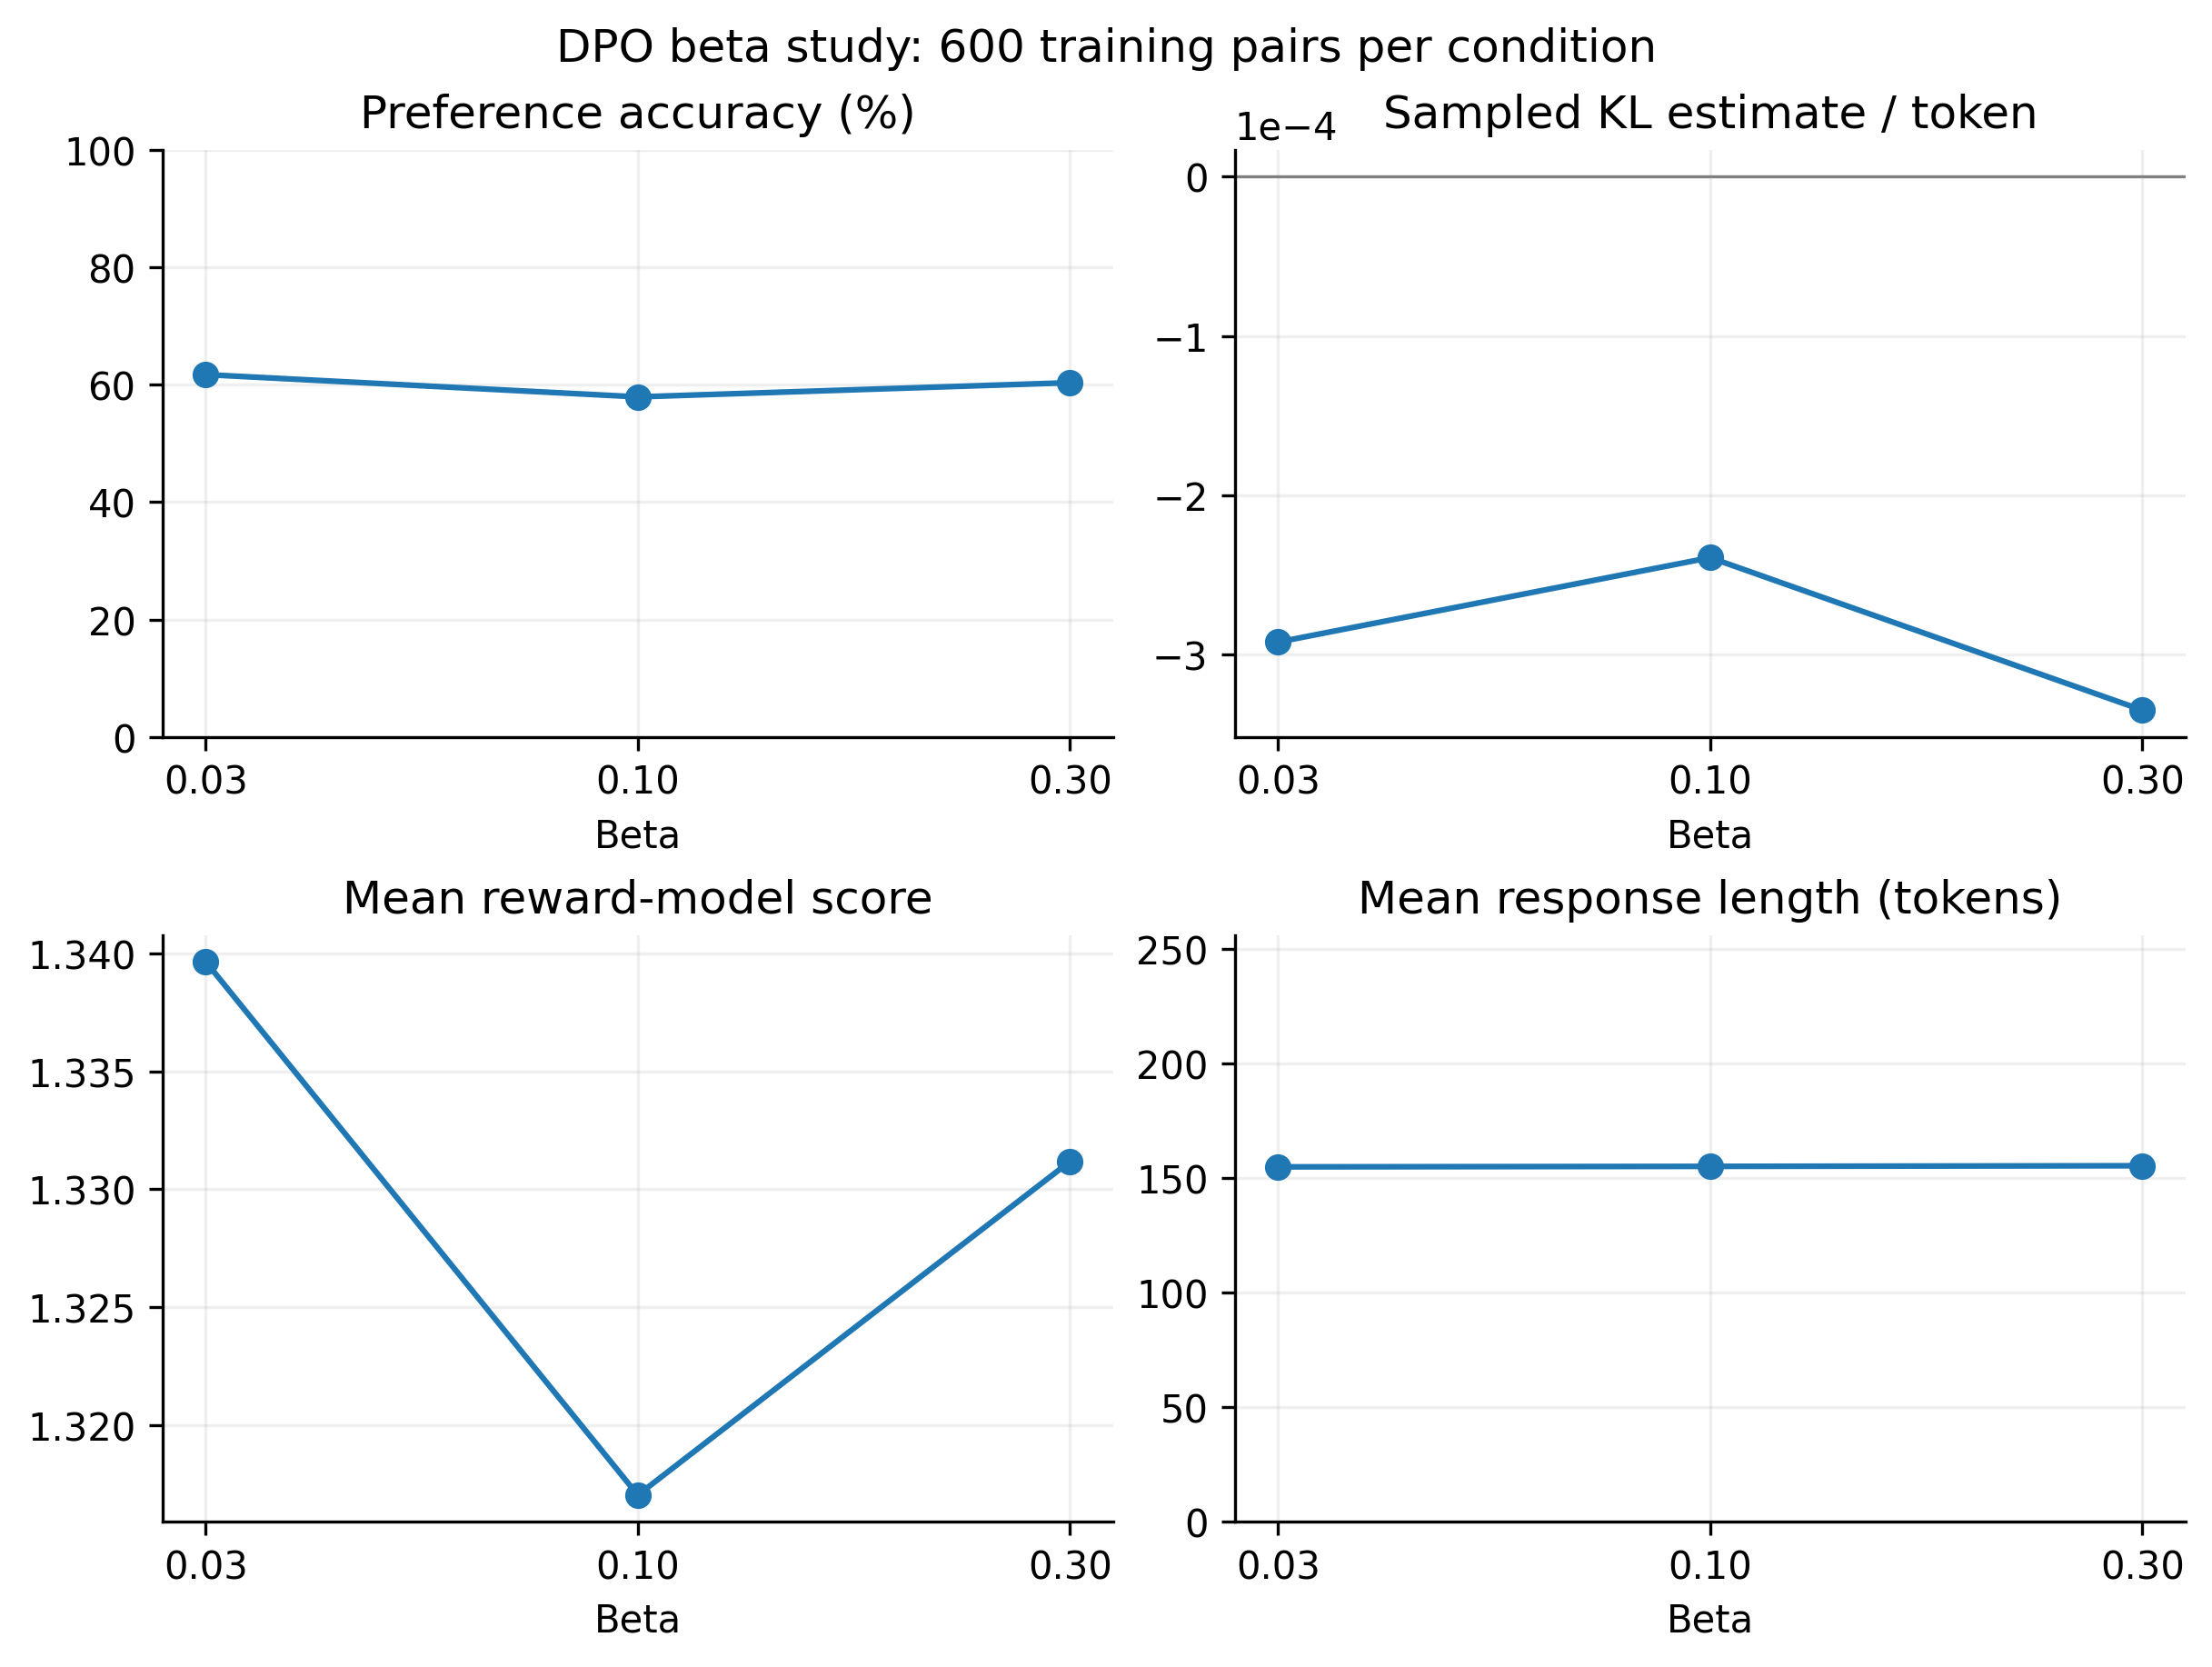

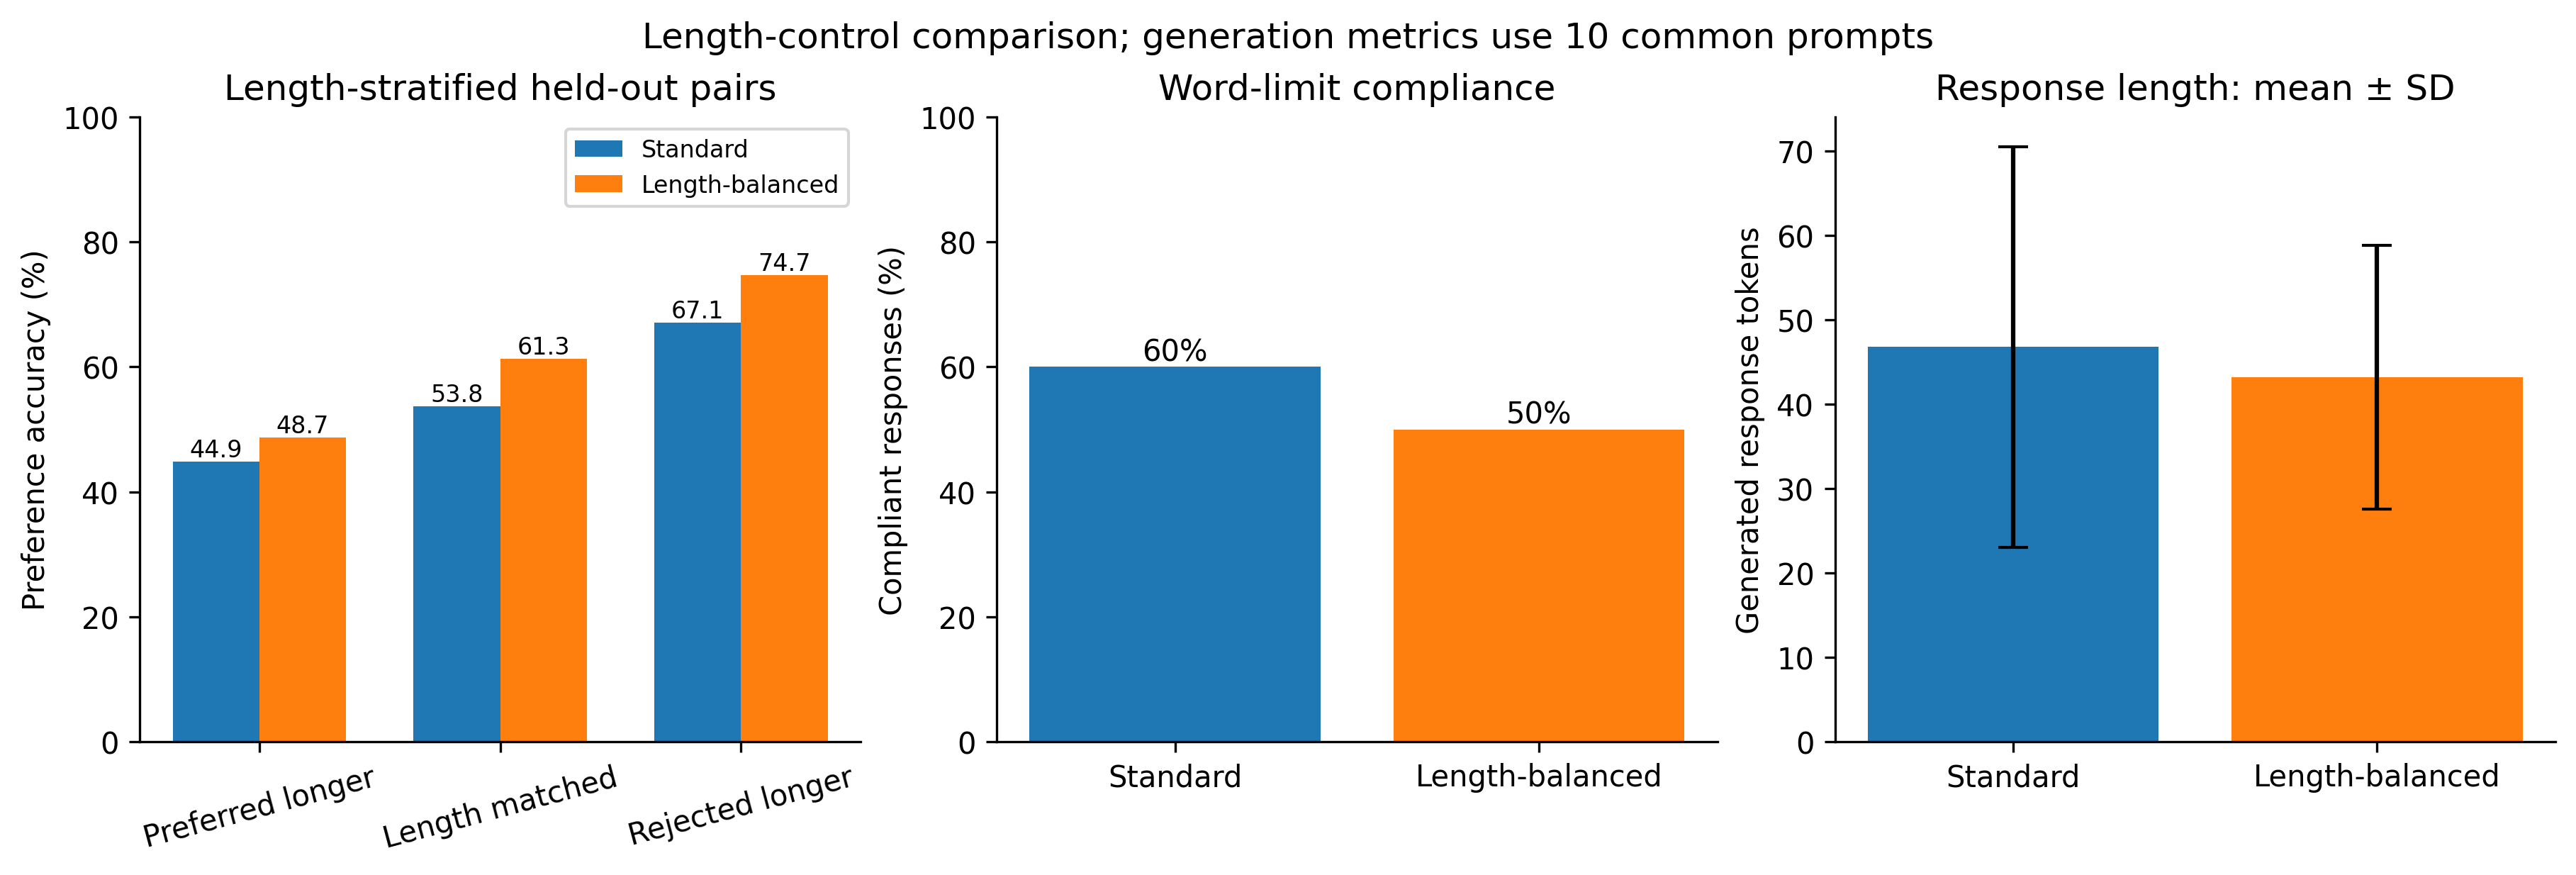

In [8]:
import subprocess
import sys
from IPython.display import Image, display

subprocess.run(
    [sys.executable, "-m", "task1_dpo.plot_results"],
    check=True,
)

display(Image(filename="report/figures/task1_beta_comparison.png"))
display(Image(filename="report/figures/task1_length_comparison.png"))